# Step 3: Build & Evaluate the Stock Index Forecast Model

**Tasks:**
1. Load PCA-reduced data
2. Train/test split (80/20)
3. Build OLS regression model (with full statistical output)
4. Evaluate: R², T-test, F-test, DW, RMSE, MAPE
5. Visualize actual vs predicted
6. Check residuals

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.stats.stattools import durbin_watson

plt.rcParams['figure.figsize'] = (12, 5)

## 1. Load PCA Data

In [4]:
df = pd.read_csv('../data/RUSSELL_pca.csv', parse_dates=['Date'], index_col='Date')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (1984, 32)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,Close
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-31,4.788935,4.960743,2.390740,-0.399538,2.125170,-1.075961,0.443272,2.377957,1.106608,0.152311,...,-0.976438,-0.556790,0.256670,0.116405,-1.585694,0.199623,0.115161,0.966420,0.227809,625.390015
2010-01-04,7.912016,3.979928,2.071828,-3.733290,1.794916,-0.460457,0.598908,1.338581,1.540812,-0.527660,...,-1.008523,0.260172,0.294496,0.221730,-1.341039,-0.448621,-0.338477,0.474086,0.305704,640.099976
2010-01-05,2.791379,5.323538,2.158877,0.048897,2.142919,-0.992573,0.972661,2.352417,1.543253,-0.222088,...,-1.528909,-1.893999,0.560752,-0.050482,-1.082581,-0.129628,0.538082,1.590308,0.225845,638.489990


## 2. Train / Test Split (80% / 20%)

**Important for time series:** we do NOT shuffle. We split by time — train on older data, test on newer data.  
This simulates real forecasting: you never know future values when predicting.

In [5]:
y = df['Close']
X = df.drop(columns=['Close'])

split_idx = int(len(df) * 0.8)
split_date = df.index[split_idx]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {len(X_train)} rows ({X_train.index[0].date()} → {X_train.index[-1].date()})')
print(f'Test:  {len(X_test)} rows ({X_test.index[0].date()} → {X_test.index[-1].date()})')

Train: 1587 rows (2009-12-31 → 2016-04-21)
Test:  397 rows (2016-04-22 → 2017-11-15)


## 3. Build OLS Regression Model

Using `statsmodels` — gives full statistical output like EViews:  
R², Adjusted R², T-statistics, p-values, F-statistic, Durbin-Watson.

In [6]:
# Add constant term (intercept b1)
X_train_const = sm.add_constant(X_train)

# Fit OLS model
model = sm.OLS(y_train, X_train_const).fit()

# Print full statistical summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     5556.
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:52:23   Log-Likelihood:                -6942.3
No. Observations:                1587   AIC:                         1.395e+04
Df Residuals:                    1555   BIC:                         1.412e+04
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1004.3284      1.066    942.354      0.0

## 4. Interpret Key Statistics

| Statistic | What to check | Pass condition |
|---|---|---|
| **R²** | Goodness of fit | > 0.7 is good |
| **Adj. R²** | R² penalized for # of variables | Should be close to R² |
| **F-statistic p-value** | Is overall model significant? | < 0.05 |
| **T-test p-values** | Is each PC significant? | < 0.05 |
| **Durbin-Watson** | Autocorrelation in residuals | Close to 2.0 |

In [7]:
print('=' * 50)
print('MODEL EVALUATION SUMMARY')
print('=' * 50)
print(f'R²              : {model.rsquared:.4f}')
print(f'Adjusted R²     : {model.rsquared_adj:.4f}')
print(f'F-statistic     : {model.fvalue:.4f}')
print(f'Prob(F-stat)    : {model.f_pvalue:.6f}  {"✓ Significant" if model.f_pvalue < 0.05 else "✗ Not significant"}')
print(f'Durbin-Watson   : {durbin_watson(model.resid):.4f}')
print(f'Observations    : {int(model.nobs)}')

# Count significant variables
sig = (model.pvalues < 0.05).sum()
total = len(model.pvalues)
print(f'Significant PCs : {sig}/{total} (p < 0.05)')

MODEL EVALUATION SUMMARY
R²              : 0.9911
Adjusted R²     : 0.9909
F-statistic     : 5556.0051
Prob(F-stat)    : 0.000000  ✓ Significant
Durbin-Watson   : 0.2296
Observations    : 1587
Significant PCs : 29/32 (p < 0.05)


## 5. Forecast on Test Set

In [8]:
X_test_const = sm.add_constant(X_test, has_constant='add')
y_pred = model.predict(X_test_const)

# Forecast accuracy metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
mae  = np.abs(y_test - y_pred).mean()

print('FORECAST ACCURACY ON TEST SET')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%  {"✓ Good (<10%)" if mape < 10 else "⚠ Check model"}')

FORECAST ACCURACY ON TEST SET
  RMSE : 82.0534
  MAE  : 71.5152
  MAPE : 5.19%  ✓ Good (<10%)


## 6. Plot: Actual vs Predicted

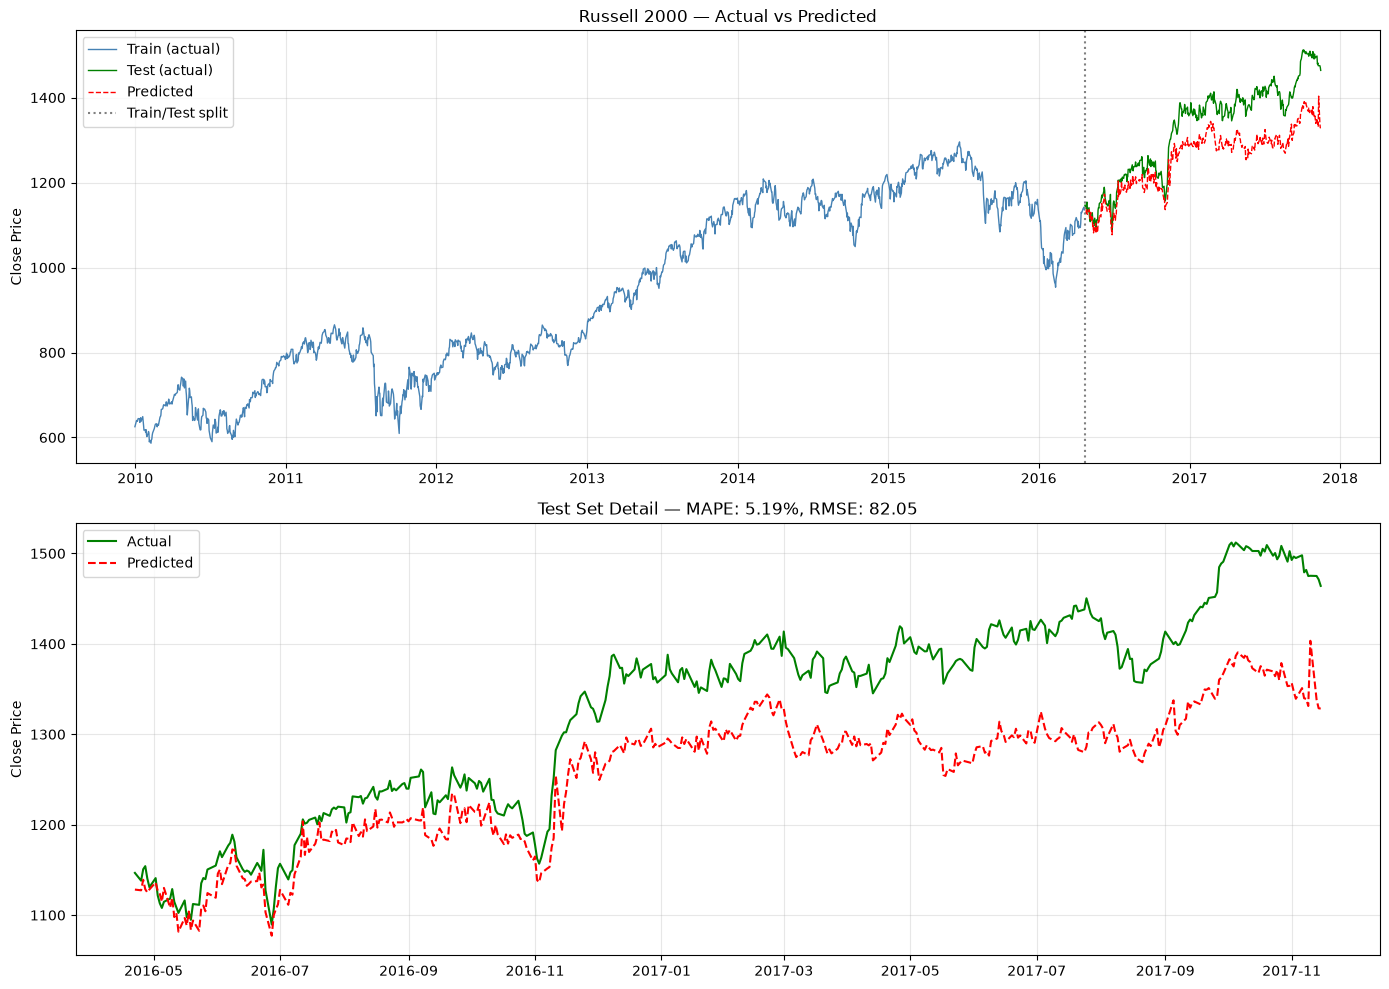

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Full series with train/test split
axes[0].plot(y_train.index, y_train, color='steelblue', label='Train (actual)', linewidth=1)
axes[0].plot(y_test.index, y_test, color='green', label='Test (actual)', linewidth=1)
axes[0].plot(y_pred.index, y_pred, color='red', linestyle='--', label='Predicted', linewidth=1)
axes[0].axvline(x=split_date, color='gray', linestyle=':', linewidth=1.5, label='Train/Test split')
axes[0].set_title('Russell 2000 — Actual vs Predicted')
axes[0].set_ylabel('Close Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test set zoom
axes[1].plot(y_test.index, y_test, color='green', label='Actual', linewidth=1.5)
axes[1].plot(y_pred.index, y_pred, color='red', linestyle='--', label='Predicted', linewidth=1.5)
axes[1].set_title(f'Test Set Detail — MAPE: {mape:.2f}%, RMSE: {rmse:.2f}')
axes[1].set_ylabel('Close Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Residual Analysis

Check if residuals are well-behaved (no patterns, approximately normal).

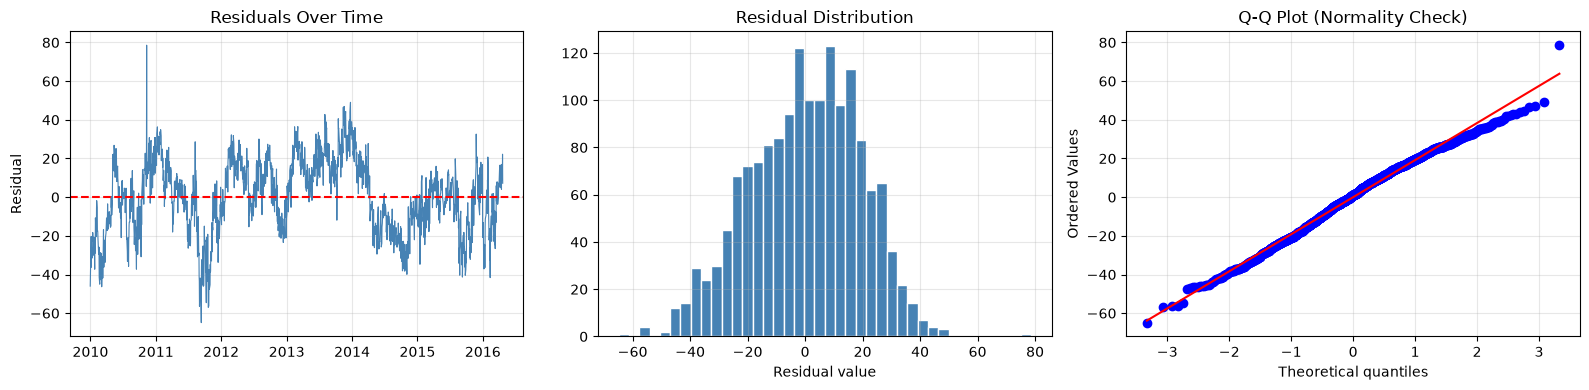

In [10]:
residuals = model.resid

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residuals over time
axes[0].plot(residuals.index, residuals, color='steelblue', linewidth=0.8)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals Over Time')
axes[0].set_ylabel('Residual')
axes[0].grid(True, alpha=0.3)

# Residual distribution
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual value')
axes[1].grid(True, alpha=0.3)

# Q-Q plot (normality check)
import scipy.stats as stats
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Final Report Summary

In [11]:
dw_val = durbin_watson(model.resid)

print('=' * 60)
print('FINAL REPORT SUMMARY — RUSSELL 2000 FORECAST MODEL')
print('=' * 60)
print(f'Dataset       : Processed_RUSSELL.csv')
print(f'Period        : {df.index[0].date()} to {df.index[-1].date()}')
print(f'Observations  : {len(df)}')
print()
print('--- Data Preparation ---')
print(f'Original variables : 84')
print(f'After removing -F  : ~65 variables')
print(f'Missing values     : filled with 5th-order moving average')
print()
print('--- PCA Reduction ---')
n_pca = X.shape[1]
print(f'Input variables  : {n_pca} (after removing Close)')
print(f'Components kept  : see notebook 02_pca.ipynb')
print(f'Variance explained: 95% threshold')
print()
print('--- Model Performance ---')
print(f'Model             : OLS Regression on PCA components')
print(f'R²                : {model.rsquared:.4f}')
print(f'Adjusted R²       : {model.rsquared_adj:.4f}')
print(f'F-statistic p-val : {model.f_pvalue:.6f}')
print(f'Durbin-Watson     : {dw_val:.4f}')
print()
print('--- Forecast Accuracy (Test Set) ---')
print(f'RMSE  : {rmse:.4f}')
print(f'MAE   : {mae:.4f}')
print(f'MAPE  : {mape:.2f}%')
print('=' * 60)

FINAL REPORT SUMMARY — RUSSELL 2000 FORECAST MODEL
Dataset       : Processed_RUSSELL.csv
Period        : 2009-12-31 to 2017-11-15
Observations  : 1984

--- Data Preparation ---
Original variables : 84
After removing -F  : ~65 variables
Missing values     : filled with 5th-order moving average

--- PCA Reduction ---
Input variables  : 31 (after removing Close)
Components kept  : see notebook 02_pca.ipynb
Variance explained: 95% threshold

--- Model Performance ---
Model             : OLS Regression on PCA components
R²                : 0.9911
Adjusted R²       : 0.9909
F-statistic p-val : 0.000000
Durbin-Watson     : 0.2296

--- Forecast Accuracy (Test Set) ---
RMSE  : 82.0534
MAE   : 71.5152
MAPE  : 5.19%


---

# IMPROVED MODEL: Log Returns (Fixing DW Problem)

**Problem:** Model 1 has DW ≈ 0.23 (strong autocorrelation) because Close price is non-stationary.

**Solution (as taught in class — EViews workflow):**
1. Test stationarity using ADF (Augmented Dickey-Fuller) test
2. Transform: `lclose = log(close)` → still non-stationary
3. Difference: `dlclose = d(lclose)` = log returns → stationary ✓
4. Rebuild OLS on log returns → DW ≈ 2.0
5. Convert predictions back to price level for evaluation

## 9. Stationarity Test (ADF — Augmented Dickey-Fuller)

The ADF test checks if a time series has a unit root (= non-stationary).
- **H₀:** Series has a unit root (non-stationary)
- **H₁:** Series is stationary
- If **p-value < 0.05** → reject H₀ → series IS stationary

In [12]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Test: {name}')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.6f}')
    print(f'  Lags Used     : {result[2]}')
    print(f'  Critical Values:')
    for key, val in result[4].items():
        print(f'    {key}: {val:.4f}')
    print(f'  Conclusion    : {"✓ STATIONARY (reject H₀)" if result[1] < 0.05 else "✗ NON-STATIONARY (fail to reject H₀)"}')
    print()

# Test 1: Raw Close price
adf_test(df['Close'], 'Close (raw price)')

# Test 2: Log of Close
log_close = np.log(df['Close'])
adf_test(log_close, 'ln(Close)')

# Test 3: Log returns = difference of log (= d(lclose) in EViews)
log_returns = log_close.diff().dropna()
adf_test(log_returns, 'Δln(Close) = log returns')

ADF Test: Close (raw price)
  ADF Statistic : -0.6630
  p-value       : 0.856098
  Lags Used     : 5
  Critical Values:
    1%: -3.4337
    5%: -2.8630
    10%: -2.5675
  Conclusion    : ✗ NON-STATIONARY (fail to reject H₀)

ADF Test: ln(Close)
  ADF Statistic : -1.3946
  p-value       : 0.584875
  Lags Used     : 25
  Critical Values:
    1%: -3.4337
    5%: -2.8630
    10%: -2.5676
  Conclusion    : ✗ NON-STATIONARY (fail to reject H₀)

ADF Test: Δln(Close) = log returns
  ADF Statistic : -9.8863
  p-value       : 0.000000
  Lags Used     : 24
  Critical Values:
    1%: -3.4337
    5%: -2.8630
    10%: -2.5676
  Conclusion    : ✓ STATIONARY (reject H₀)



## 10. Visualize: Close vs ln(Close) vs Log Returns

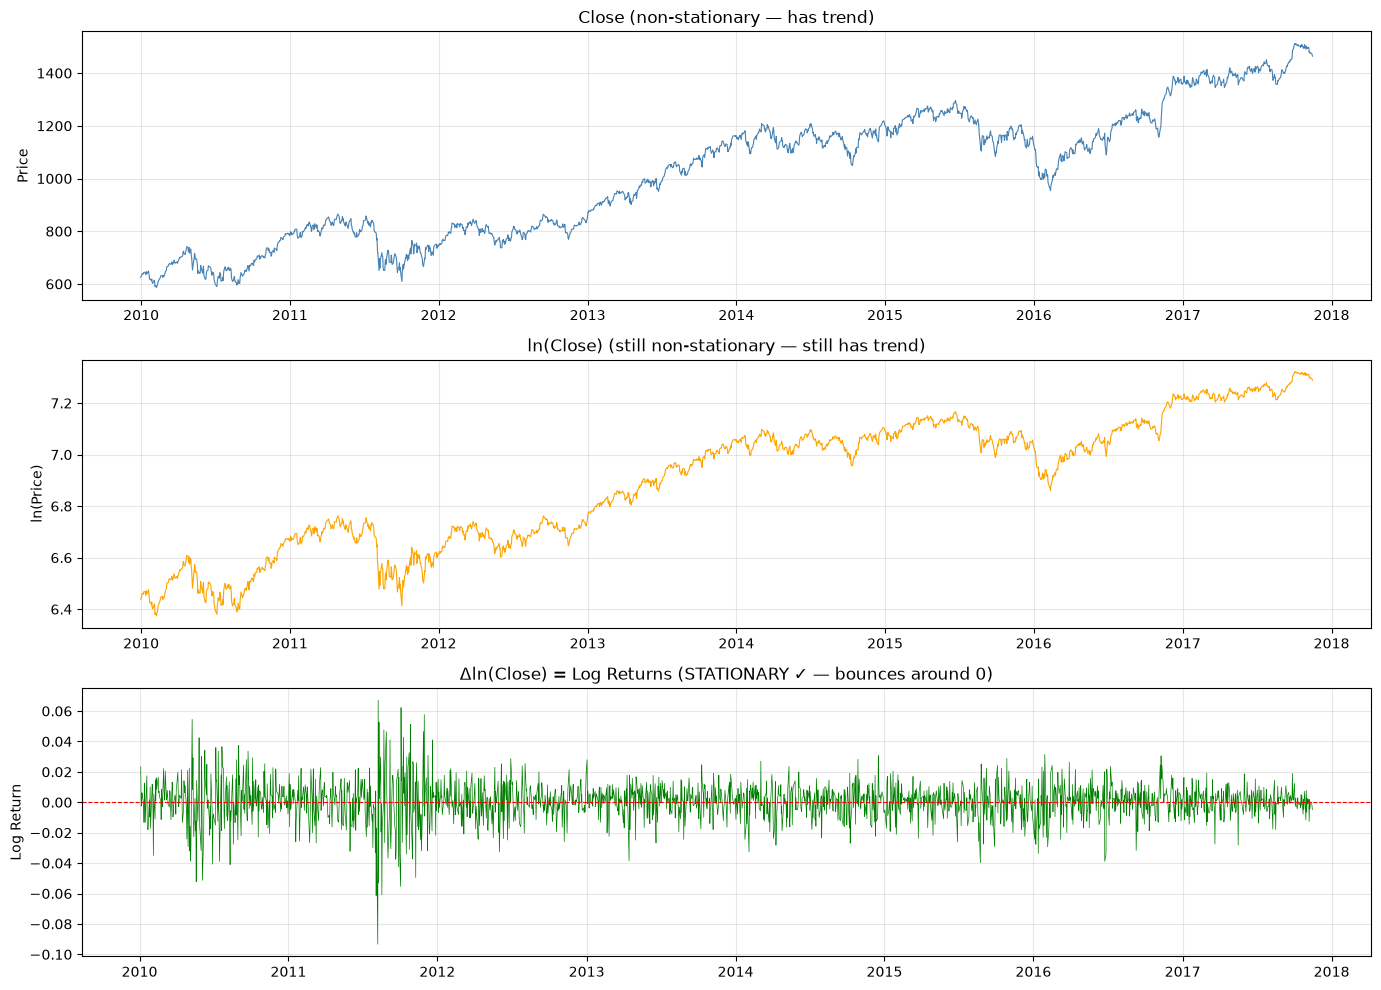

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df['Close'], color='steelblue', linewidth=0.8)
axes[0].set_title('Close (non-stationary — has trend)')
axes[0].set_ylabel('Price')
axes[0].grid(True, alpha=0.3)

axes[1].plot(log_close, color='orange', linewidth=0.8)
axes[1].set_title('ln(Close) (still non-stationary — still has trend)')
axes[1].set_ylabel('ln(Price)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(log_returns, color='green', linewidth=0.5)
axes[2].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[2].set_title('Δln(Close) = Log Returns (STATIONARY ✓ — bounces around 0)')
axes[2].set_ylabel('Log Return')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Rebuild OLS Model on Log Returns

Now we use **Δln(Close) = log returns** as the dependent variable (Y).  
The PCA components (X) are the same — they are already stationary-like after standardization.

In [14]:
# Prepare log returns as target variable
y_log = log_returns  # Δln(Close)
X_log = X.iloc[1:]   # drop first row to align with diff()

# Train/test split (same 80/20, time-ordered)
split_idx2 = int(len(X_log) * 0.8)
split_date2 = X_log.index[split_idx2]

X_train2 = X_log.iloc[:split_idx2]
X_test2 = X_log.iloc[split_idx2:]
y_train2 = y_log.iloc[:split_idx2]
y_test2 = y_log.iloc[split_idx2:]

print(f'Train: {len(X_train2)} rows')
print(f'Test:  {len(X_test2)} rows')

# Fit OLS on log returns
X_train2_const = sm.add_constant(X_train2)
model2 = sm.OLS(y_train2, X_train2_const).fit()

print(model2.summary())

Train: 1586 rows
Test:  397 rows
                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.870
Method:                 Least Squares   F-statistic:                     344.3
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:52:24   Log-Likelihood:                 6204.3
No. Observations:                1586   AIC:                        -1.234e+04
Df Residuals:                    1554   BIC:                        -1.217e+04
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.00

## 12. Improved Model Evaluation

In [15]:
dw_val2 = durbin_watson(model2.resid)

print('=' * 60)
print('IMPROVED MODEL — LOG RETURNS')
print('=' * 60)
print(f'R²              : {model2.rsquared:.4f}')
print(f'Adjusted R²     : {model2.rsquared_adj:.4f}')
print(f'F-statistic     : {model2.fvalue:.4f}')
print(f'Prob(F-stat)    : {model2.f_pvalue:.6f}  {"✓ Significant" if model2.f_pvalue < 0.05 else "✗ Not significant"}')
print(f'Durbin-Watson   : {dw_val2:.4f}  {"✓ No autocorrelation" if 1.5 < dw_val2 < 2.5 else "⚠ Check"}')
print(f'Observations    : {int(model2.nobs)}')

sig2 = (model2.pvalues < 0.05).sum()
total2 = len(model2.pvalues)
print(f'Significant PCs : {sig2}/{total2} (p < 0.05)')

IMPROVED MODEL — LOG RETURNS
R²              : 0.8729
Adjusted R²     : 0.8704
F-statistic     : 344.3055
Prob(F-stat)    : 0.000000  ✓ Significant
Durbin-Watson   : 2.1091  ✓ No autocorrelation
Observations    : 1586
Significant PCs : 22/32 (p < 0.05)


## 13. Convert Predictions Back to Price Level & Evaluate

To compare fairly with the price model, we convert log-return predictions back to actual prices:
$$\text{Close}_t = \text{Close}_{t-1} \times e^{\hat{r}_t}$$

In [16]:
# Predict log returns on test set
X_test2_const = sm.add_constant(X_test2, has_constant='add')
y_pred_log = model2.predict(X_test2_const)

# Convert back to price: Close_t = Close_{t-1} * exp(predicted_log_return)
close_values = df['Close']
price_pred = []
prev_price = close_values.iloc[split_idx2]  # last training price

for lr in y_pred_log:
    next_price = prev_price * np.exp(lr)
    price_pred.append(next_price)
    prev_price = next_price

price_pred = pd.Series(price_pred, index=y_test2.index)

# Get actual Close prices for comparison
y_test_price = close_values.iloc[split_idx2 + 1 : split_idx2 + 1 + len(price_pred)]

# Align lengths
min_len = min(len(price_pred), len(y_test_price))
price_pred = price_pred.iloc[:min_len]
y_test_price = y_test_price.iloc[:min_len]

# Accuracy metrics on price level
rmse2 = np.sqrt(mean_squared_error(y_test_price, price_pred))
mape2 = mean_absolute_percentage_error(y_test_price, price_pred) * 100
mae2 = np.abs(y_test_price - price_pred.values).mean()

print('FORECAST ACCURACY — IMPROVED MODEL (price level)')
print(f'  RMSE : {rmse2:.4f}')
print(f'  MAE  : {mae2:.4f}')
print(f'  MAPE : {mape2:.2f}%')

FORECAST ACCURACY — IMPROVED MODEL (price level)
  RMSE : 126.6946
  MAE  : 93.8368
  MAPE : 6.73%


## Actual vs Predicted — Log Returns Model (Price Level)

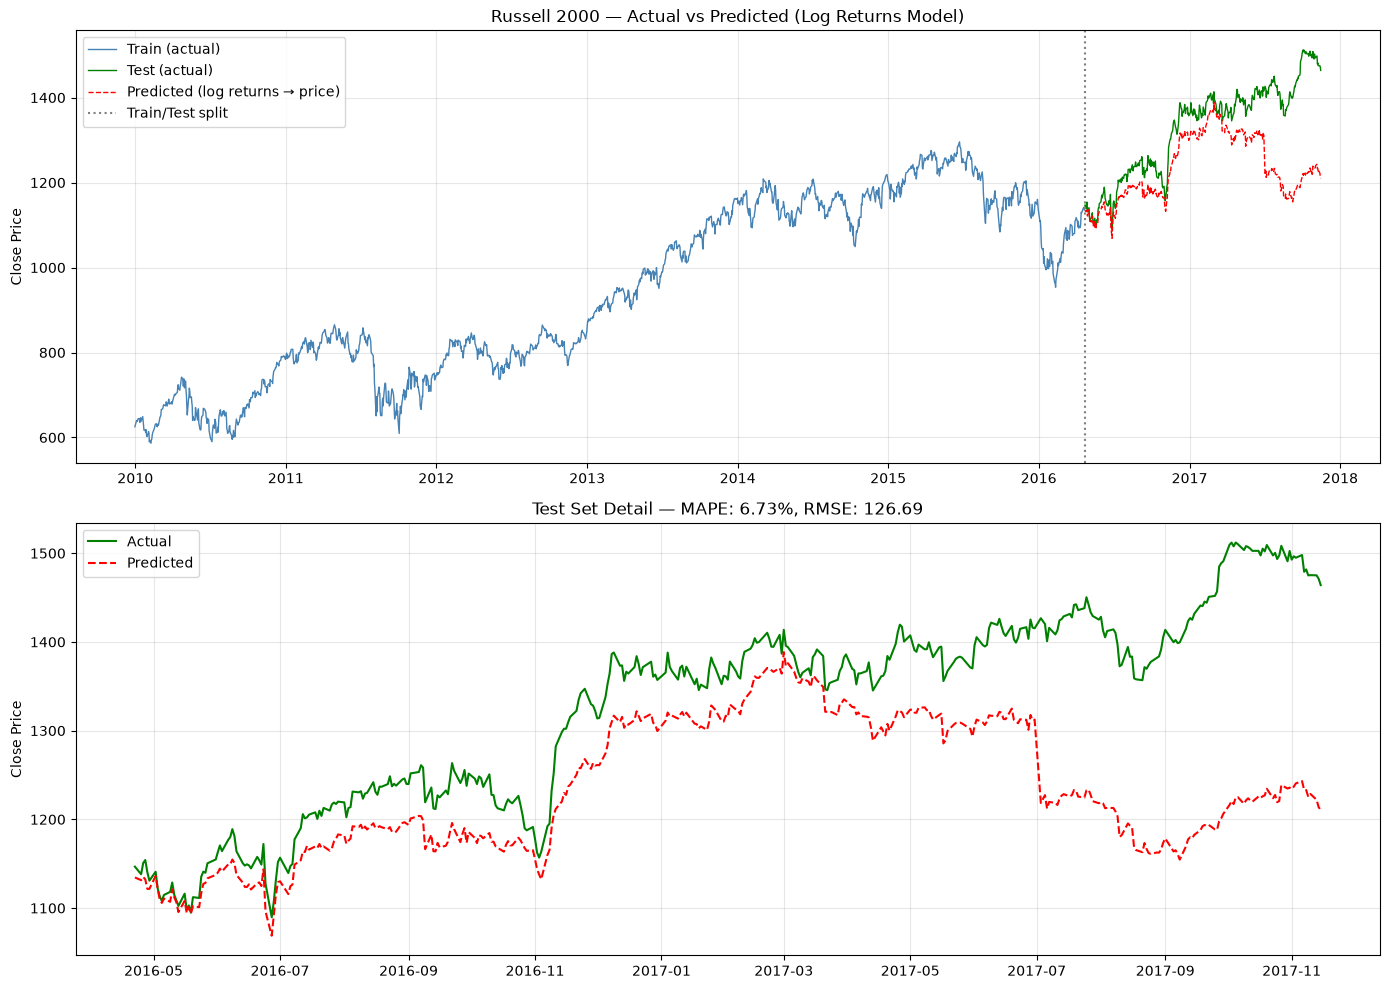

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Full series with train/test split
axes[0].plot(y_train.index, y_train, color='steelblue', label='Train (actual)', linewidth=1)
axes[0].plot(y_test_price.index, y_test_price, color='green', label='Test (actual)', linewidth=1)
axes[0].plot(price_pred.index, price_pred, color='red', linestyle='--', label='Predicted (log returns → price)', linewidth=1)
axes[0].axvline(x=split_date2, color='gray', linestyle=':', linewidth=1.5, label='Train/Test split')
axes[0].set_title('Russell 2000 — Actual vs Predicted (Log Returns Model)')
axes[0].set_ylabel('Close Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test set zoom
axes[1].plot(y_test_price.index, y_test_price, color='green', label='Actual', linewidth=1.5)
axes[1].plot(price_pred.index, price_pred, color='red', linestyle='--', label='Predicted', linewidth=1.5)
axes[1].set_title(f'Test Set Detail — MAPE: {mape2:.2f}%, RMSE: {rmse2:.2f}')
axes[1].set_ylabel('Close Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Residual Analysis — Improved Model

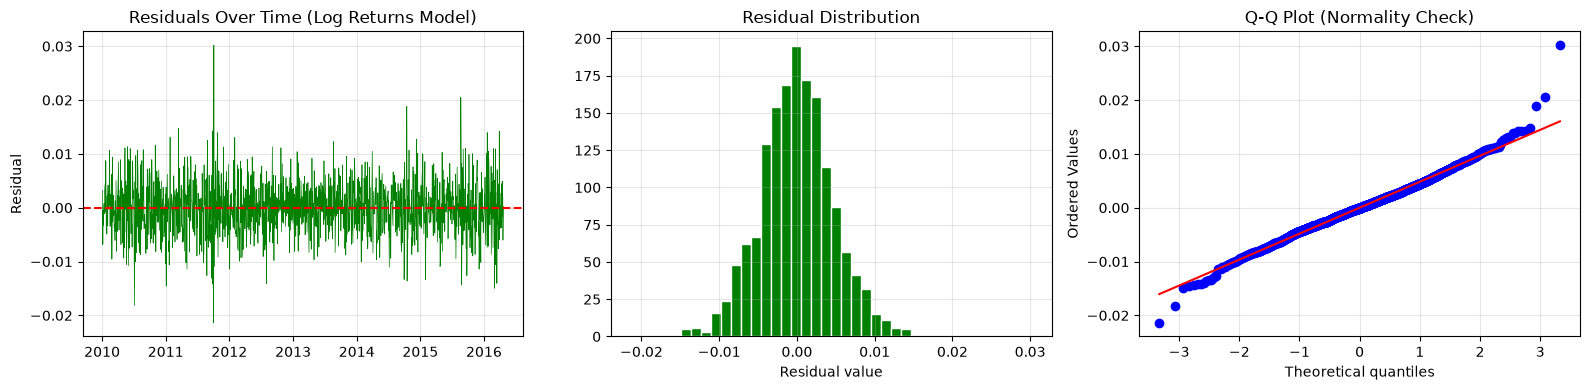

In [17]:
import scipy.stats as stats

residuals2 = model2.resid

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(residuals2.index, residuals2, color='green', linewidth=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals Over Time (Log Returns Model)')
axes[0].set_ylabel('Residual')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals2, bins=40, color='green', edgecolor='white')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual value')
axes[1].grid(True, alpha=0.3)

stats.probplot(residuals2, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 15. Comparison: Price Model vs Log Returns Model

In [18]:
print('=' * 65)
print('MODEL COMPARISON')
print('=' * 65)
print(f'{"Metric":<25} {"Price Model":<20} {"Log Returns Model":<20}')
print('-' * 65)
print(f'{"R²":<25} {model.rsquared:<20.4f} {model2.rsquared:<20.4f}')
print(f'{"Adjusted R²":<25} {model.rsquared_adj:<20.4f} {model2.rsquared_adj:<20.4f}')
print(f'{"Durbin-Watson":<25} {dw_val:<20.4f} {dw_val2:<20.4f}')
print(f'{"F-stat p-value":<25} {model.f_pvalue:<20.6f} {model2.f_pvalue:<20.6f}')
print(f'{"RMSE":<25} {rmse:<20.4f} {rmse2:<20.4f}')
print(f'{"MAE":<25} {mae:<20.4f} {mae2:<20.4f}')
print(f'{"MAPE":<25} {mape:<20.2f}% {mape2:<19.2f}%')
print('=' * 65)
print()
print('Key improvement:')
print(f'  DW: {dw_val:.4f} → {dw_val2:.4f}  ({"✓ FIXED — no autocorrelation" if 1.5 < dw_val2 < 2.5 else "improved"})')
print(f'  R²: {model.rsquared:.4f} → {model2.rsquared:.4f}  (lower but honest — not inflated by trend)')
print()
print('Conclusion:')
print('  The Price Model has inflated R² due to non-stationarity (trend in Close price).')
print('  The Log Returns Model correctly handles stationarity and eliminates autocorrelation.')

MODEL COMPARISON
Metric                    Price Model          Log Returns Model   
-----------------------------------------------------------------
R²                        0.9911               0.8729              
Adjusted R²               0.9909               0.8704              
Durbin-Watson             0.2296               2.1091              
F-stat p-value            0.000000             0.000000            
RMSE                      82.0534              126.6946            
MAE                       71.5152              93.8368             
MAPE                      5.19                % 6.73               %

Key improvement:
  DW: 0.2296 → 2.1091  (✓ FIXED — no autocorrelation)
  R²: 0.9911 → 0.8729  (lower but honest — not inflated by trend)

Conclusion:
  The Price Model has inflated R² due to non-stationarity (trend in Close price).
  The Log Returns Model correctly handles stationarity and eliminates autocorrelation.
